# 선행지표를 찾는 3가지 방법

후행지표(예: **D7 잔존**)는 결과가 나오기까지 시간이 걸려 즉각적인 진단이 어렵습니다.
그래서 후행지표를 미리 가늠할 **선행지표(leading indicator)** 를 함께 찾아 관리합니다.

이 노트북은 **하나의 신규 유저 이벤트 로그**(`data/event_log.csv`)를 가지고, "신규 유저의
D7 잔존을 끌어올릴 선행지표"를 **세 가지 방법**으로 찾아봅니다. *같은 데이터·같은 타깃,
세 가지 렌즈*입니다.

1. **EDA 비교** — 잔존/비잔존 코호트의 D0~D1 행동을 발생 비중·평균 횟수로 비교
2. **SHAP Value** — 잔존을 예측하는 모델을 만들고 각 행동의 기여도를 분해
3. **Sankey Diagram** — 설치 직후 행동 흐름을 그리고, 어느 갈림길에서 잔존이 갈리는지 색으로 확인

마지막에는 세 방법이 공통으로 가리키는 선행지표를 **삼각측량**으로 정리합니다.

## 0. 준비

아래 셀이 의존성을 설치합니다. 데이터가 없다면 먼저 터미널에서 `python generate_data.py` 를 실행해 `data/event_log.csv` 를 만들어 주세요.

In [1]:
# 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# DuckDB 인메모리 연결 하나를 만들어 노트북 전체에서 재사용합니다.
con = duckdb.connect()
con.execute(
    "CREATE OR REPLACE TABLE event_log AS "
    "SELECT * FROM read_csv_auto('data/event_log.csv')"
)
con.query(
    "SELECT COUNT(*) AS event_rows, COUNT(DISTINCT user_id) AS users FROM event_log"
).to_df()

,event_rows,users
0,136391,12000


In [3]:
# 로그 한 줄은 유저의 이벤트 한 번을 의미합니다.
con.query(
    "SELECT * FROM event_log ORDER BY user_id, event_timestamp LIMIT 8"
).to_df()

,event_timestamp,event_date,user_id,event_name,screen_name,event_count,description
0,2026-01-02 01:01:24,2026-01-02,u000000,application_install,app,1,앱 설치
1,2026-01-02 01:01:32,2026-01-02,u000000,page_view_onboarding_step,onboarding,1,온보딩 단계 조회
2,2026-01-02 01:01:44,2026-01-02,u000000,tutorial_complete,onboarding,1,튜토리얼 완료
3,2026-01-02 01:01:56,2026-01-02,u000000,page_view_home,home,1,메인 홈 조회
4,2026-01-02 01:02:38,2026-01-02,u000000,content_view,content_detail,3,메인 콘텐츠 상세 조회
5,2026-01-02 01:02:43,2026-01-02,u000000,like_content,content_detail,1,콘텐츠 좋아요
6,2026-01-02 01:02:52,2026-01-02,u000000,search_used,search,1,검색 사용
7,2026-01-02 01:03:09,2026-01-02,u000000,search_used,search,2,검색 사용


---
## 실습 1. EDA로 선행지표 후보 찾기

가장 먼저 할 일은 **탐색**입니다. 미리 정해둔 가설 없이 모든 이벤트를 펼쳐 놓고, 잔존 유저와
비잔존 유저가 **무엇을 다르게 하는지** 살펴봅니다. 명확한 인과는 아니지만, 두 코호트의 행동
차이에서 선행지표 후보를 얻을 수 있습니다.

### 1-1. 분석 모수·D7 잔존 라벨링

설치(D0) 유저를 모수로 두고, 설치 후 **7일째 활동이 있으면 D7 잔존(=1)** 으로 라벨링합니다.

In [20]:
label_query = """
WITH base AS (
    SELECT user_id, MIN(event_date) AS install_date
    FROM event_log
    WHERE event_name = 'application_install'
    GROUP BY 1
)
SELECT b.user_id
     , MAX(CASE WHEN date_diff('day', b.install_date, e.event_date) = 7 THEN 1 ELSE 0 END) AS d7_retention_flag
FROM base AS b
LEFT JOIN event_log AS e ON b.user_id = e.user_id
GROUP BY 1
"""
labels = con.query(label_query).to_df()
(labels["d7_retention_flag"]
    .value_counts(normalize=True)
    .rename(index={0: "비잔존(0)", 1: "잔존(1)"})
    .mul(100).round(1).rename("share(%)").to_frame())

,share(%)
d7_retention_flag,
비잔존(0),60.30
잔존(1),39.70


### 1-2. D0~D1 행동 집계 — 코호트 비교

라벨이 붙었으니, **D0~D1 구간**의 행동을 이벤트별로 집계해 두 코호트를 비교합니다.
- `share` : 그 행동을 한 번이라도 한 유저 비중 (코호트 내 %)
- `avg_event_count` : 그 행동을 한 유저들의 평균 발생 횟수

`share_diff`(잔존 − 비잔존) 내림차순으로 정렬하면, 잔존 유저가 **특별히 많이 하는 행동**이
위로 올라옵니다. (쿼리는 `sql/eda_leading_indicator.sql` 에도 있습니다.)

In [21]:
eda_query = """
-- 실습 1) EDA로 선행지표 후보 찾기
-- 신규 설치(D0) 유저를 D7 잔존/비잔존으로 라벨링하고, D0~D1 구간 행동의
-- 발생 비중(share)과 평균 횟수(avg_event_count)를 코호트별로 비교한다.
-- 잔존 유저가 특별히 많이/자주 하는 행동을 선행지표 후보로 추려 본다.
WITH log_data AS (
    -- raw 이벤트 로그를 (유저, 이벤트, 화면, 일자) 단위 발생 횟수로 집계
    SELECT event_date
         , event_name
         , screen_name
         , user_id
         , SUM(event_count) AS event_count
         , MAX(description)  AS description
    FROM event_log
    WHERE event_date BETWEEN DATE '2026-01-01' AND DATE '2026-01-31'
    GROUP BY 1, 2, 3, 4
),
retention_label AS (
    -- 설치(D0) 시점과 D7 잔존 여부를 라벨링
    SELECT i.event_date
         , i.user_id
         , MAX(CASE WHEN date_diff('day', i.event_date, l.event_date) = 7 THEN 1 ELSE 0 END) AS d7_retention_flag
    FROM (
        SELECT event_date, user_id
        FROM log_data
        WHERE event_name = 'application_install'
        GROUP BY 1, 2
    ) AS i
    LEFT JOIN (
        SELECT event_date, user_id FROM log_data GROUP BY 1, 2
    ) AS l
      ON i.user_id = l.user_id
     AND l.event_date > i.event_date
     AND date_diff('day', i.event_date, l.event_date) <= 7
    GROUP BY 1, 2
),
population AS (
    SELECT d7_retention_flag
         , COUNT(DISTINCT user_id) AS total_user_cnt
    FROM retention_label
    GROUP BY 1
),
event_stat AS (
    -- D0 ~ D1 구간의 행동만 집계
    SELECT r.d7_retention_flag
         , l.event_name
         , l.screen_name
         , COUNT(DISTINCT r.user_id) AS user_cnt
         , AVG(l.event_count)        AS avg_event_count
         , MAX(l.description)        AS description
    FROM retention_label AS r
    LEFT JOIN log_data AS l
      ON r.user_id    = l.user_id
     AND l.event_date >= r.event_date
     AND date_diff('day', r.event_date, l.event_date) <= 1
    GROUP BY 1, 2, 3
),
cohort_info AS (
    SELECT e.d7_retention_flag
         , e.event_name
         , e.screen_name
         , e.user_cnt
         , p.total_user_cnt
         , (e.user_cnt * 1.0 / p.total_user_cnt) * 100 AS share
         , e.avg_event_count
    FROM event_stat AS e
    LEFT JOIN population AS p
      ON e.d7_retention_flag = p.d7_retention_flag
)
SELECT event_name
     , screen_name
     , MAX(CASE WHEN d7_retention_flag = 0 THEN share           END) AS d7_ret0_share
     , MAX(CASE WHEN d7_retention_flag = 0 THEN avg_event_count END) AS d7_ret0_avg_cnt
     , MAX(CASE WHEN d7_retention_flag = 1 THEN share           END) AS d7_ret1_share
     , MAX(CASE WHEN d7_retention_flag = 1 THEN avg_event_count END) AS d7_ret1_avg_cnt
     , MAX(CASE WHEN d7_retention_flag = 1 THEN share END)
     - MAX(CASE WHEN d7_retention_flag = 0 THEN share END)           AS share_diff
     , MAX(CASE WHEN d7_retention_flag = 1 THEN avg_event_count END)
     - MAX(CASE WHEN d7_retention_flag = 0 THEN avg_event_count END) AS event_cnt_diff
FROM cohort_info
WHERE event_name IS NOT NULL
GROUP BY 1, 2
HAVING d7_ret1_share >= 10 OR d7_ret0_share >= 10
ORDER BY share_diff DESC
"""

eda = con.query(eda_query).to_df()
eda.sort_values("share_diff", ascending=False).round(1)

,event_name,screen_name,d7_ret0_share,d7_ret0_avg_cnt,d7_ret1_share,d7_ret1_avg_cnt,share_diff,event_cnt_diff
0,like_content,content_detail,28.10,1.50,74.90,2.30,46.80,0.80
1,content_view,content_detail,58.80,3.80,100.00,4.80,41.20,0.90
2,share_content,content_detail,16.80,1.20,51.10,1.60,34.30,0.40
3,tutorial_complete,onboarding,46.00,1.00,77.80,1.00,31.70,0.00
4,search_used,search,6.70,3.70,30.60,5.70,23.90,1.90
5,push_allow,permission,41.10,1.00,62.90,1.00,21.90,0.00
6,application_install,app,100.00,1.00,100.00,1.00,0.00,0.00
7,page_view_onboarding_step,onboarding,100.00,1.00,100.00,1.00,0.00,0.00
8,page_view_home,home,100.00,1.00,100.00,1.00,0.00,0.00
9,page_view_profile,profile,27.40,1.00,5.80,1.00,-21.50,0.00


### 1-3. 해석·시각화

표만으로도 이야기가 보입니다. 잔존 유저는 **튜토리얼 완료·콘텐츠 조회·좋아요**를 훨씬 높은
비중으로 합니다. 반대로 **에러 팝업·내정보/설정** 비중은 비잔존 쪽이 높습니다. 막대그래프로
잔존 vs 비잔존 share를 나란히 보면 격차가 한눈에 들어옵니다.

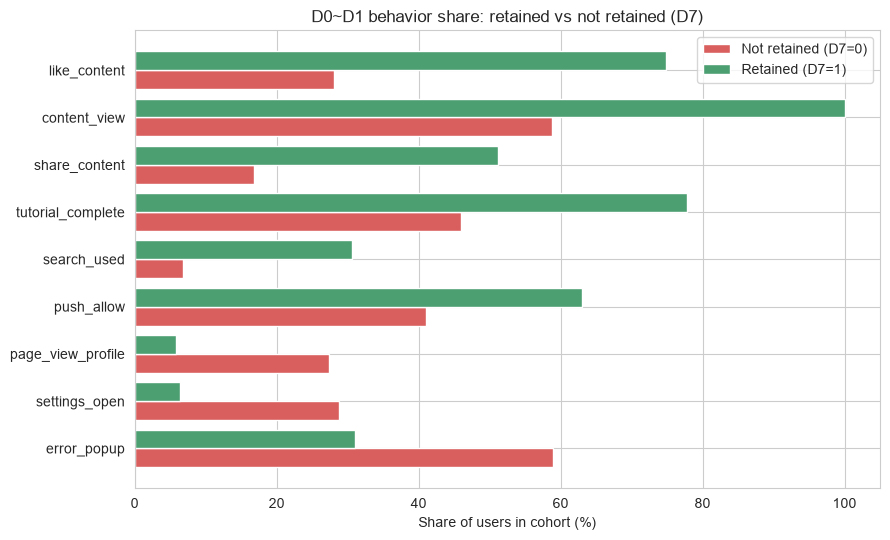

In [22]:
plot_df = (eda.assign(abs_diff=eda["share_diff"].abs())
              .sort_values("abs_diff", ascending=False)
              .head(9)
              .sort_values("share_diff"))

y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(y - 0.2, plot_df["d7_ret0_share"], height=0.4, label="Not retained (D7=0)", color="#d95f5f")
ax.barh(y + 0.2, plot_df["d7_ret1_share"], height=0.4, label="Retained (D7=1)", color="#4c9f70")
ax.set_yticks(y); ax.set_yticklabels(plot_df["event_name"])
ax.set_xlabel("Share of users in cohort (%)")
ax.set_title("D0~D1 behavior share: retained vs not retained (D7)")
ax.legend()
plt.tight_layout(); plt.show()

`search_used`(검색)는 결이 다른 신호입니다. 수행 **비중(share)** 은 낮지만, 하는 유저는
**여러 번** 합니다 — 즉 평균 발생 횟수(`avg_event_count`)는 잔존 유저가 월등히 높습니다.
비중만 봐서는 놓치기 쉬운, 횟수로 드러나는 선행지표 후보입니다.

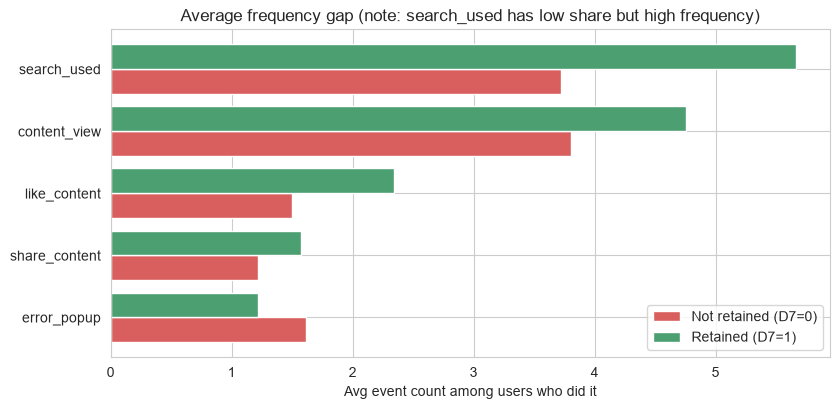

In [23]:
spot = eda[eda["event_name"].isin(
    ["content_view", "like_content", "search_used", "share_content", "error_popup"])
].sort_values("d7_ret1_avg_cnt")

y = np.arange(len(spot))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(y - 0.2, spot["d7_ret0_avg_cnt"], height=0.4, label="Not retained (D7=0)", color="#d95f5f")
ax.barh(y + 0.2, spot["d7_ret1_avg_cnt"], height=0.4, label="Retained (D7=1)", color="#4c9f70")
ax.set_yticks(y); ax.set_yticklabels(spot["event_name"])
ax.set_xlabel("Avg event count among users who did it")
ax.set_title("Average frequency gap (note: search_used has low share but high frequency)")
ax.legend()
plt.tight_layout(); plt.show()

---
## 실습 2. SHAP으로 기여도 정량화

EDA가 후보를 던져 줬다면, 이제 **여러 행동을 동시에 놓고** 각 행동이 잔존 예측에 얼마나, 어떤
방향으로 기여하는지 정량화할 차례입니다. D7 잔존을 예측하는 **LGBM** 모델을 만들고,
**SHAP Value** 로 기여도를 분해합니다. 모델 자체의 정확도를 끌어올리는 게 목적이 아니라,
"어떤 행동이 예측을 끌어올리는가"를 읽기 위한 도구로 모델을 씁니다.

### 2-1. 피처 행렬·라벨 준비

설치 첫 세션(D0)의 행동을 유저 단위 피처로 집계하고 D7 잔존을 라벨로 붙입니다.
(쿼리는 `sql/feature_matrix.sql` 에도 있습니다.)

In [8]:
fm_query = """
-- 실습 2) 유저별 행동 피처 행렬 + D7 잔존 라벨
-- 설치 첫 세션(D0)의 행동을 유저 단위 피처로 집계하고, D7 잔존 여부를 라벨로 붙인다.
-- 이 행렬로 LGBM 모델을 학습시켜 SHAP으로 각 행동의 기여도를 분해한다.
WITH base AS (
    SELECT user_id
         , MIN(event_timestamp) AS install_ts
         , MIN(event_date)      AS install_date
    FROM event_log
    WHERE event_name = 'application_install'
    GROUP BY 1
),
labeled AS (
    -- 설치 이후 7일째 활동이 있으면 D7 잔존
    SELECT b.user_id
         , MAX(CASE WHEN date_diff('day', b.install_date, e.event_date) = 7 THEN 1 ELSE 0 END) AS d7_retention_flag
    FROM base AS b
    LEFT JOIN event_log AS e ON b.user_id = e.user_id
    GROUP BY 1
),
d0_session AS (
    -- 설치 당일(D0) 세션 이벤트만
    SELECT e.user_id
         , e.event_name
         , e.event_count
         , e.event_timestamp
    FROM base AS b
    JOIN event_log AS e
      ON b.user_id = e.user_id
     AND date_diff('day', b.install_date, e.event_date) = 0
),
feat AS (
    SELECT user_id
         , COUNT(*) FILTER (WHERE event_name = 'content_view')      AS content_view
         , COUNT(*) FILTER (WHERE event_name = 'like_content')      AS like_content
         , COUNT(*) FILTER (WHERE event_name = 'search_used')       AS search_used
         , COUNT(*) FILTER (WHERE event_name = 'share_content')     AS share_content
         , COUNT(*) FILTER (WHERE event_name = 'page_view_profile') AS profile_view
         , COUNT(*) FILTER (WHERE event_name = 'settings_open')     AS settings_open
         , COUNT(*) FILTER (WHERE event_name = 'error_popup')       AS error_popup
         , MAX(CASE WHEN event_name = 'tutorial_complete' THEN 1 ELSE 0 END) AS tutorial_complete
         , MAX(CASE WHEN event_name = 'push_allow'        THEN 1 ELSE 0 END) AS push_allow
         -- 설치 세션 길이(초): 첫 이벤트 ~ 마지막 이벤트
         , date_diff('second', MIN(event_timestamp), MAX(event_timestamp)) AS session_duration_sec
    FROM d0_session
    GROUP BY 1
)
SELECT l.d7_retention_flag
     , f.user_id
     , f.tutorial_complete
     , f.push_allow
     , f.content_view
     , f.like_content
     , f.search_used
     , f.share_content
     , f.profile_view
     , f.settings_open
     , f.error_popup
     , f.session_duration_sec
FROM labeled AS l
JOIN feat AS f ON l.user_id = f.user_id
"""

fm = con.query(fm_query).to_df()
y = fm["d7_retention_flag"]
# 예측에 쓰지 않는 식별자/라벨 컬럼은 제외
X = fm.drop(columns=["d7_retention_flag", "user_id"])

from sklearn.model_selection import train_test_split
# stratify 로 클래스 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=314, stratify=y)
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
tutorial_complete,"12,000.00",0.59,0.49,0.00,0.00,1.00,1.00,1.00
push_allow,"12,000.00",0.50,0.50,0.00,0.00,0.00,1.00,1.00
content_view,"12,000.00",1.59,1.70,0.00,0.00,1.00,3.00,8.00
like_content,"12,000.00",0.95,1.34,0.00,0.00,0.00,2.00,8.00
search_used,"12,000.00",0.56,1.44,0.00,0.00,0.00,0.00,6.00
share_content,"12,000.00",0.44,0.79,0.00,0.00,0.00,1.00,6.00
profile_view,"12,000.00",0.19,0.39,0.00,0.00,0.00,0.00,1.00
settings_open,"12,000.00",0.20,0.40,0.00,0.00,0.00,0.00,1.00
error_popup,"12,000.00",0.73,0.91,0.00,0.00,0.00,1.00,3.00
session_duration_sec,"12,000.00",119.36,82.55,9.00,56.00,99.00,162.00,541.00


### 2-2. 베이스라인 LGBM 학습·평가

먼저 고정 하이퍼파라미터로 기준 모델을 학습합니다. 검증 AUC가 10라운드 동안 개선되지 않으면
멈춥니다(early stopping). 클래스 불균형은 `class_weight='balanced'` 로 보정합니다.

In [9]:
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)

baseline = lgb.LGBMClassifier(
    num_leaves=15, max_depth=-1, n_estimators=1000, learning_rate=0.01,
    colsample_bytree=0.9, subsample=0.9, subsample_freq=1,
    class_weight="balanced", random_state=314, n_jobs=4, metric="None", verbose=-1,
)
baseline.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], eval_metric="auc",
    callbacks=[lgb.early_stopping(10, verbose=False)],
)

def report(model, tag):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba > 0.5).astype(int)
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    print(f"[{tag}]  accuracy={acc:.4f}  AUC={auc:.4f}  best_iter={model.best_iteration_}")
    return acc, auc

base_acc, base_auc = report(baseline, "baseline")

[baseline]  accuracy=0.7717  AUC=0.8548  best_iter=36


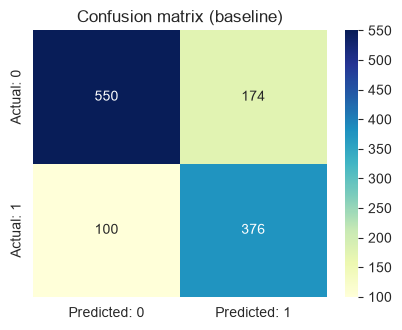

              precision    recall  f1-score   support

           0      0.846     0.760     0.801       724
           1      0.684     0.790     0.733       476

    accuracy                          0.772      1200
   macro avg      0.765     0.775     0.767      1200
weighted avg      0.782     0.772     0.774      1200



In [10]:
# 혼동 행렬 (행=실제, 열=예측)
proba = baseline.predict_proba(X_test)[:, 1]
pred = (proba > 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
cm_df = pd.DataFrame(cm, index=["Actual: 0", "Actual: 1"],
                         columns=["Predicted: 0", "Predicted: 1"])
plt.figure(figsize=(4.2, 3.4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion matrix (baseline)")
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred, digits=3))

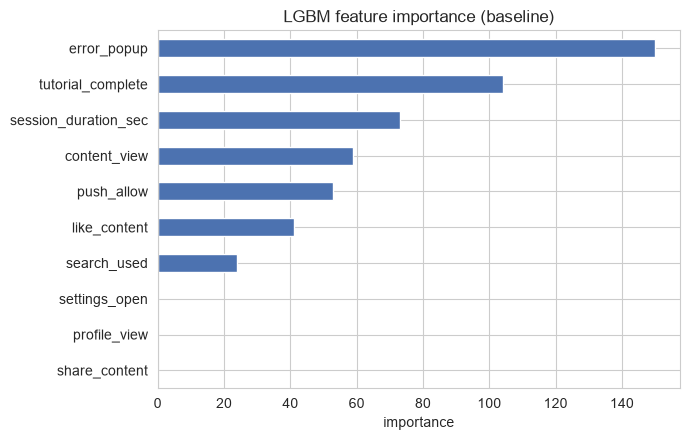

In [11]:
# Feature importance — 어떤 피처가 분기에 많이 쓰였나 (방향성은 알 수 없음)
imp = pd.Series(baseline.feature_importances_, index=X.columns).sort_values()
imp.plot(kind="barh", figsize=(7, 4.5), color="#4c72b0")
plt.title("LGBM feature importance (baseline)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

### 2-3. Optuna로 하이퍼파라미터 최적화

해석용 모델이라 화려한 튜닝이 꼭 필요하진 않지만, **Optuna** 로 교차검증 AUC를 목적함수 삼아
하이퍼파라미터를 좀 더 깊이 탐색해 볼 수 있습니다. 샘플러 시드를 고정해 재현 가능하게 두고,
탐색 횟수(`n_trials`)는 실습용으로 작게 잡습니다.

In [12]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        num_leaves=trial.suggest_int("num_leaves", 8, 64),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        n_estimators=300,
        min_child_samples=trial.suggest_int("min_child_samples", 10, 120),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        class_weight="balanced", random_state=314, n_jobs=4, verbose=-1,
    )
    model = lgb.LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=314)
    return cross_val_score(model, X_train, y_train, cv=skf, scoring="roc_auc").mean()

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=314))
study.optimize(objective, n_trials=25, show_progress_bar=False)
print(f"best CV AUC = {study.best_value:.4f}")
study.best_params

best CV AUC = 0.8580


{'num_leaves': 8,
 'learning_rate': 0.016826104963074903,
 'min_child_samples': 119,
 'colsample_bytree': 0.6998025760772738,
 'subsample': 0.7532175834062731}

In [13]:
# 최적 파라미터로 재학습 후 베이스라인과 비교
best_params = {**study.best_params, "n_estimators": 1000, "subsample_freq": 1,
               "class_weight": "balanced", "random_state": 314, "n_jobs": 4,
               "metric": "None", "verbose": -1}
clf = lgb.LGBMClassifier(**best_params)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="auc",
        callbacks=[lgb.early_stopping(10, verbose=False)])
tuned_acc, tuned_auc = report(clf, "optuna-tuned")

pd.DataFrame({
    "accuracy": [base_acc, tuned_acc],
    "AUC":      [base_auc, tuned_auc],
}, index=["baseline", "optuna-tuned"]).round(4)

[optuna-tuned]  accuracy=0.7825  AUC=0.8626  best_iter=169


,accuracy,AUC
baseline,0.77,0.85
optuna-tuned,0.78,0.86


해석용 모델에서는 1~2%의 정확도 차이가 결론을 바꾸지 않는 경우가 많습니다. 튜닝은
"조금 더 나은 모델로 기여도를 본다" 정도의 의미이고, 이제 이 모델로 SHAP을 그립니다.

### 2-4. SHAP summary plot

SHAP summary plot은 한 장에 많은 걸 담습니다.
- **가로축(SHAP value)** : 오른쪽일수록 그 행동이 **잔존 예측을 끌어올림**
- **색** : 그 피처 값의 크기 (빨강=높음, 파랑=낮음)

예를 들어 `content_view`가 빨강(많이 봄)일수록 오른쪽(잔존↑)에 모이면, "콘텐츠를 많이 볼수록
잔존이 올라간다"는 관계를 읽을 수 있습니다.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


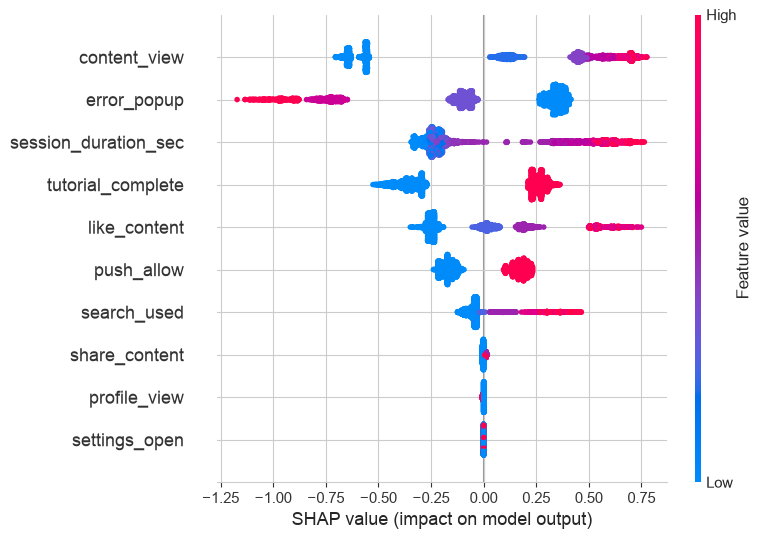

In [14]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(clf.booster_)
X_shap = X_train.sample(frac=0.3, random_state=314)
shap_values = explainer.shap_values(X_shap)
# 이진 분류에서 리스트로 반환되면 양성 클래스 기준 사용
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_shap, show=True)

### 2-5. SHAP dependence plot — 임계값(아하 모먼트) 탐색

SHAP은 데이터 row 단위로 계산되므로, **피처 값에 따라 기여도가 어떻게 변하는지** 곡선으로 볼 수
있습니다. 값이 커지다가 기여도가 **양수로 꺾이는 임계점**이 보이면, 그게 곧 "아하 모먼트"
후보입니다. (색은 `content_view`와의 상호작용)

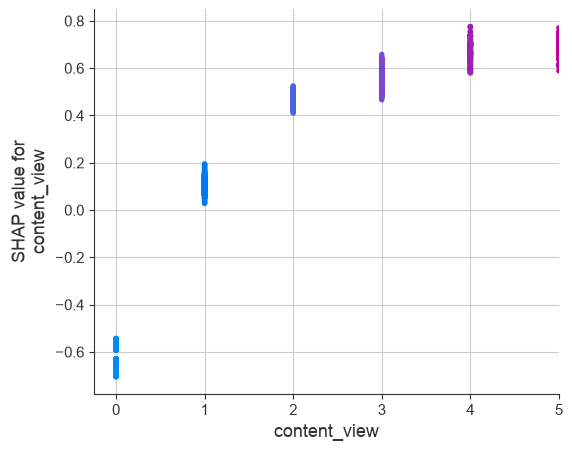

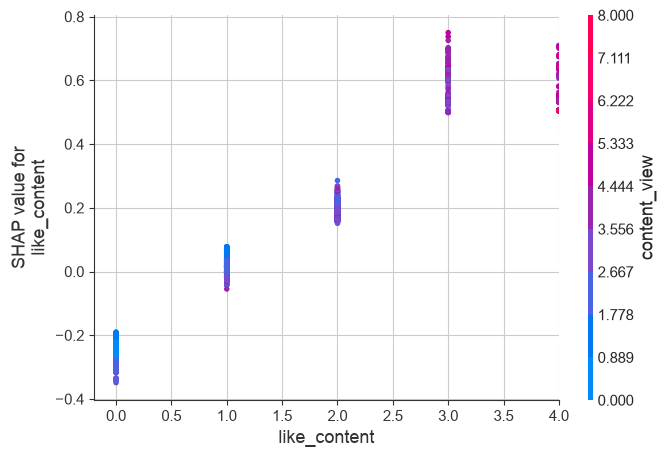

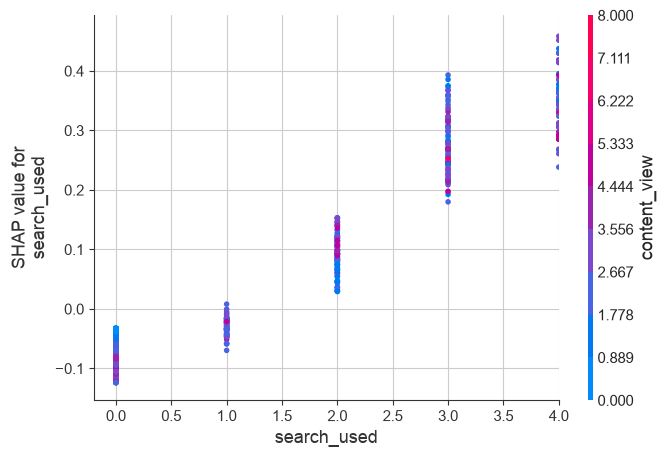

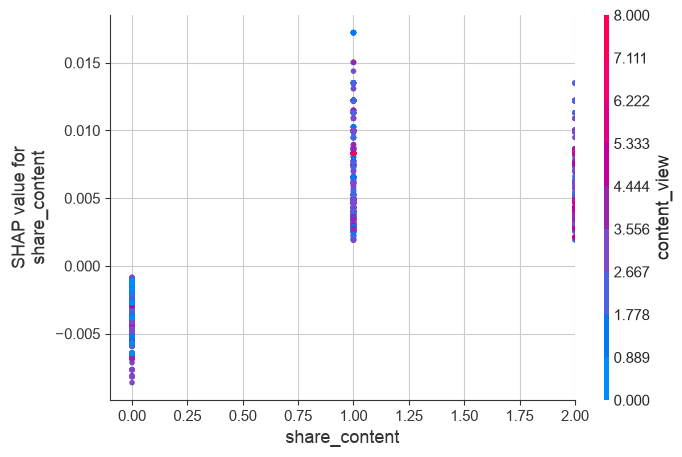

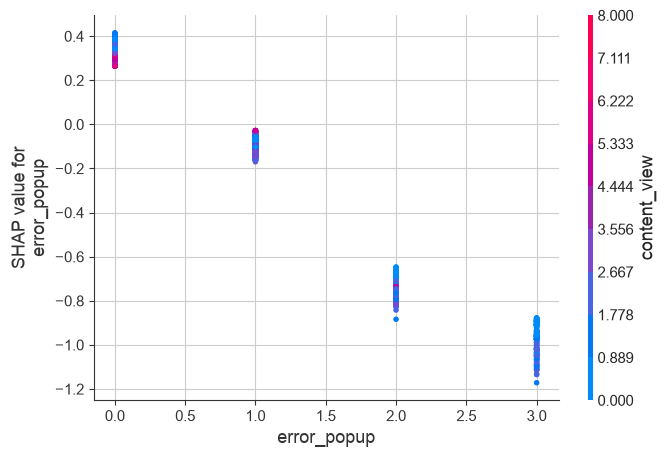

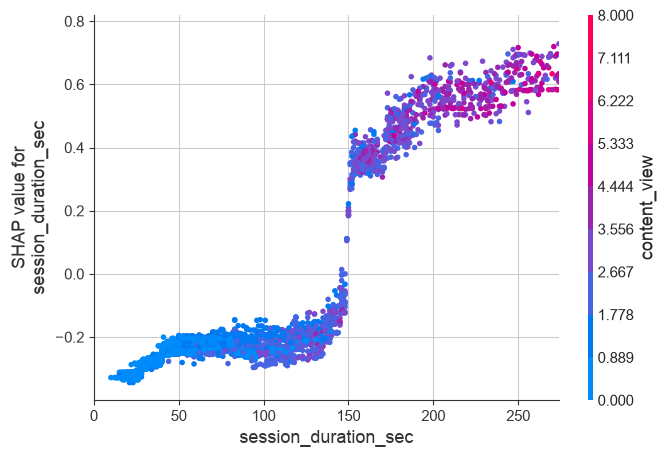

In [15]:
NUMERIC = ["content_view", "like_content", "search_used",
           "share_content", "error_popup", "session_duration_sec"]

for name in NUMERIC:
    xs = X_shap
    xmax = xs[name].quantile(0.95)
    if xmax == 0:
        xmax = max(xs[name].max(), 1)
    shap.dependence_plot(
        name, sv, xs,
        interaction_index="content_view",
        xmin=0, xmax=xmax, show=True,
    )

`session_duration_sec`는 약 **150초** 부근에서, `like_content`는 **3회** 부근에서 SHAP 값이
양수로 꺾이는 게 보입니다. "첫 세션 2분 30초 이상 / 좋아요 3회 이상"처럼, 막연한 행동을
**구체적인 선행지표 목표**로 바꿔 제안할 수 있습니다.

---
## 실습 3. Sankey로 잔존이 갈리는 흐름 찾기

지금까지는 행동을 **개별 이벤트**로 봤습니다. 마지막은 **흐름(flow)** 입니다. 설치 직후 유저가
거치는 화면·행동을 순서대로 잇고, 각 전이를 지나간 유저들의 **D7 잔존율로 색칠**합니다.
그러면 *같은 갈림길에서 어느 쪽으로 가면 잔존이 떨어지는지*가 색으로 드러납니다.

### 3-1. 스텝 전이 쿼리

설치 후 1시간 이내 이벤트를 순서대로 늘어놓고(연속 중복 제거), 스텝 N → N+1 전이를 만들어
전이별 유저 수와 D7 잔존율을 집계합니다. 스텝 위치마다 상위 `TOP_K` 이벤트만 남기고 나머지는
`ETC`로 묶어 그림을 읽기 쉽게 합니다. (쿼리는 `sql/sankey_transitions.sql` 에도 있습니다.)

In [16]:
# CONFIG — 분석을 조절하는 값들
MAX_STEPS = 10    # 유저당 처음 N개 이벤트
TOP_K     = 6     # 스텝별 상위 K개 이벤트 (나머지는 ETC)
MIN_USERS = 20    # 링크로 그릴 최소 유저 수

sankey_query = f"""
WITH base AS (
    SELECT user_id, MIN(event_timestamp) AS install_ts, MIN(event_date) AS install_date
    FROM event_log
    WHERE event_name = 'application_install'
    GROUP BY 1
),
user_retention AS (
    SELECT b.user_id,
           MAX(CASE WHEN date_diff('day', b.install_date, e.event_date) = 7 THEN 1 ELSE 0 END) AS d7_retained
    FROM base AS b
    LEFT JOIN event_log AS e ON b.user_id = e.user_id
    GROUP BY 1
),
session_events AS (
    SELECT b.user_id, e.event_name, e.event_timestamp,
           LAG(e.event_name) OVER (PARTITION BY b.user_id ORDER BY e.event_timestamp) AS prev_event
    FROM base AS b
    JOIN event_log AS e
      ON b.user_id = e.user_id
     AND e.event_timestamp >= b.install_ts
     AND e.event_timestamp <= b.install_ts + INTERVAL 1 HOUR
),
deduped AS (
    SELECT user_id, event_name, event_timestamp
    FROM session_events
    WHERE prev_event IS NULL OR event_name != prev_event
),
user_steps AS (
    SELECT user_id, event_name, event_timestamp,
           ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY event_timestamp) AS step_num
    FROM deduped
    QUALIFY step_num <= {MAX_STEPS}
),
event_volume AS (
    SELECT step_num, event_name, COUNT(DISTINCT user_id) AS user_cnt,
           ROW_NUMBER() OVER (PARTITION BY step_num ORDER BY COUNT(DISTINCT user_id) DESC) AS rnk
    FROM user_steps
    GROUP BY 1, 2
),
top_events AS (SELECT step_num, event_name FROM event_volume WHERE rnk <= {TOP_K}),
steps_resolved AS (
    SELECT s.user_id, s.step_num,
           CASE WHEN t.event_name IS NOT NULL THEN s.event_name ELSE 'ETC' END AS event_name
    FROM user_steps AS s
    LEFT JOIN top_events AS t ON s.step_num = t.step_num AND s.event_name = t.event_name
),
transitions AS (
    SELECT a.user_id, a.step_num AS from_step,
           CAST(a.step_num AS VARCHAR) || '-' || a.event_name AS source,
           CAST(b.step_num AS VARCHAR) || '-' || b.event_name AS target
    FROM steps_resolved AS a
    JOIN steps_resolved AS b ON a.user_id = b.user_id AND b.step_num = a.step_num + 1
)
SELECT t.from_step, t.source, t.target,
       COUNT(DISTINCT t.user_id) AS user_count,
       COUNT(DISTINCT CASE WHEN r.d7_retained = 1 THEN t.user_id END) * 100.0
         / NULLIF(COUNT(DISTINCT t.user_id), 0) AS d7_retention
FROM transitions AS t
LEFT JOIN user_retention AS r ON t.user_id = r.user_id
GROUP BY 1, 2, 3
HAVING COUNT(DISTINCT t.user_id) >= {MIN_USERS}
ORDER BY from_step, user_count DESC
"""

flows = con.query(sankey_query).to_df()
print(f"transitions: {flows.shape[0]} rows | "
      f"D7 retention range: {flows['d7_retention'].min():.1f}% ~ {flows['d7_retention'].max():.1f}%")
flows.head(12)

transitions: 84 rows | D7 retention range: 2.6% ~ 86.7%


,from_step,source,target,user_count,d7_retention
0,1,1-application_install,2-page_view_onboarding_step,12000,39.67
1,2,2-page_view_onboarding_step,3-tutorial_complete,7034,52.63
2,2,2-page_view_onboarding_step,3-page_view_home,2809,14.95
3,2,2-page_view_onboarding_step,3-push_allow,2157,29.62
4,3,3-tutorial_complete,4-push_allow,3813,61.84
5,3,3-tutorial_complete,4-page_view_home,3221,41.73
6,3,3-push_allow,4-page_view_home,2157,29.62
7,3,3-page_view_home,4-content_view,1196,27.59
8,3,3-page_view_home,4-settings_open,834,5.52
9,3,3-page_view_home,4-page_view_profile,779,5.65


### 3-2. 잔존율로 색칠한 Sankey

링크 **두께 = 유저 수**, 링크 **색 = D7 잔존율**(빨강=낮음 → 초록=높음)입니다. 같은 노드에서
갈라지는 링크의 색을 비교하면 어느 분기가 잔존을 떨어뜨리는지 보입니다.

In [17]:
import plotly.graph_objects as go
import plotly.io as pio
# notebook_connected: plotly.js 를 CDN 에서 불러와 노트북 파일을 가볍게 유지
pio.renderers.default = "notebook_connected"

labels = list(pd.unique(flows[["source", "target"]].values.ravel()))
label_to_idx = {lab: i for i, lab in enumerate(labels)}
flows["source_idx"] = flows["source"].map(label_to_idx)
flows["target_idx"] = flows["target"].map(label_to_idx)

# 노드 잔존율 = 들어오는 링크의 유저수 가중 평균
node_ret = {}
for lab in labels:
    inc = flows[flows["target"] == lab]
    use = inc if len(inc) else flows[flows["source"] == lab]
    node_ret[lab] = (np.average(use["d7_retention"], weights=use["user_count"])
                     if len(use) else 0.0)

ret_min, ret_max = flows["d7_retention"].quantile(0.1), flows["d7_retention"].quantile(0.9)

def ret_to_rgba(ret, alpha=0.55):
    t = np.clip((ret - ret_min) / max(ret_max - ret_min, 1), 0, 1)
    if t < 0.5:  # red -> amber
        s = t * 2; r, g, b = 220 + s*20, 50 + s*130, 50
    else:        # amber -> green
        s = (t - 0.5) * 2; r, g, b = 240 - s*190, 180, 50 + s*30
    return f"rgba({int(r)},{int(g)},{int(b)},{alpha})"

link_colors = [ret_to_rgba(r) for r in flows["d7_retention"]]
node_colors = [ret_to_rgba(node_ret[l], 0.85) for l in labels]
node_disp = [f"{l}  ({node_ret[l]:.0f}%)" for l in labels]
link_hover = [f"{r.user_count:,} users | D7 retention: {r.d7_retention:.1f}%"
              for r in flows.itertuples()]

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(pad=22, thickness=20, line=dict(color="#333", width=0.6),
              label=node_disp, color=node_colors,
              hovertemplate="%{label}<extra></extra>"),
    link=dict(source=flows["source_idx"], target=flows["target_idx"],
              value=flows["user_count"], color=link_colors, customdata=link_hover,
              hovertemplate="%{source.label} → %{target.label}<br>%{customdata}<extra></extra>"),
))
fig.update_layout(
    title="Install-session flow → D7 retention (link color = retention rate)",
    font=dict(size=11), width=1800, height=720, paper_bgcolor="#fafafa")
fig.show()

### 3-3. 잔존이 갈리는 분기 진단

색만으로도 보이지만, 같은 출발점에서 갈라지는 전이를 잔존율로 직접 비교하면 더 분명합니다.

In [18]:
# 같은 source 에서 갈라지는 전이들 (잔존율 차이가 큰 분기 위주)
flows["ret_gap_at_source"] = flows.groupby("source")["d7_retention"].transform(
    lambda s: s.max() - s.min())
branches = (flows[flows["ret_gap_at_source"] > 15]
            .sort_values(["ret_gap_at_source", "source", "d7_retention"],
                         ascending=[False, True, False]))
branches[["from_step", "source", "target", "user_count", "d7_retention"]].head(14).round(1)

,from_step,source,target,user_count,d7_retention
19,5,5-page_view_home,6-content_view,2834,74.60
24,5,5-page_view_home,6-page_view_profile,475,24.80
23,5,5-page_view_home,6-settings_open,504,24.80
62,8,8-like_content,9-content_view,415,74.50
68,8,8-like_content,9-search_used,97,74.20
63,8,8-like_content,9-share_content,310,71.30
65,8,8-like_content,9-error_popup,117,29.90
50,7,7-like_content,8-share_content,737,79.60
48,7,7-like_content,8-content_view,1258,78.70
57,7,7-like_content,8-search_used,103,72.80


In [19]:
print("=" * 70, "\nTOP transitions by D7 retention (min 50 users)\n", "=" * 70)
top = flows[flows["user_count"] >= 50].nlargest(8, "d7_retention")
for r in top.itertuples():
    print(f"  {r.source:>28s} -> {r.target:<26s}  {r.user_count:>5,}u  {r.d7_retention:5.1f}%")

print("\n", "=" * 70, "\nBOTTOM transitions by D7 retention (min 50 users)\n", "=" * 70)
bot = flows[flows["user_count"] >= 50].nsmallest(8, "d7_retention")
for r in bot.itertuples():
    print(f"  {r.source:>28s} -> {r.target:<26s}  {r.user_count:>5,}u  {r.d7_retention:5.1f}%")

TOP transitions by D7 retention (min 50 users)
                9-like_content -> 10-content_view               641u   86.7%
                9-like_content -> 10-share_content              428u   83.9%
                9-content_view -> 10-like_content               803u   83.6%
               8-share_content -> 9-content_view                677u   82.1%
               9-share_content -> 10-content_view               329u   80.9%
                8-content_view -> 9-like_content              1,450u   80.3%
                7-like_content -> 8-share_content               737u   79.6%
                7-like_content -> 8-content_view              1,258u   78.7%

BOTTOM transitions by D7 retention (min 50 users)
           4-page_view_profile -> 5-error_popup                 547u    2.6%
               4-settings_open -> 5-error_popup                 535u    3.6%
              3-page_view_home -> 4-settings_open               834u    5.5%
              3-page_view_home -> 4-page_view_profile  